# Can one portfolio survive both a crash AND an inflation spike? 🐉
### The Dragon Portfolio — a real diversification story, wrapped around one sleeve you (probably) can't buy cheaply

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![A_cheap_ETF_Dragon%3F: Busted](https://img.shields.io/badge/A_cheap_ETF_Dragon%3F-Busted-8b949e?style=flat-square)

Chris Cole, a hedge-fund manager known for tail-risk trading, built a **100-year backtest** arguing the classic 60/40 stocks-and-bonds mix has a blind spot: it has nothing that *profits* when everything else craters at once — 2008, March 2020. His fix, the "Dragon Portfolio", adds two extra sleeves most portfolios skip: **commodity trend-following** and **long volatility** — insurance that pays off exactly when stocks and bonds fail together.

We can't rebuild his 100-year backtest (that data isn't public). What we *can* do is buy the cheapest available version with real ETFs and see what actually happens on the tape since 2007 — including the two best real-world tests we have: the 2020 crash and the 2022 inflation shock.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dragon_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.prices_frame(tickers=("SPY", "TLT", "GLD", "DBC", "VXX", "SHY"))
    RET = st.build_returns(PX)
    RF = RET["SHY"]
else:
    PX = RET = RF = None
print("real cache present:", HAVE_REAL, "| tickers:",
      (0 if PX is None else PX.notna().sum().to_dict()))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fp_prices': '3dd12240ccde', 'core_start': '2007-02-01', 'full_start': '2018-03-01', 'core_n': 4883, 'full_n': 2094, 'dl_cagr': 7.82, 'dl_vol': 9.22, 'dl_sharpe': 0.668, 'dl_dd': -26.4, 'dl_w12': -21.0, 'p6040_core_cagr': 8.3, 'p6040_core_vol': 11.21, 'p6040_core_sharpe': 0.601, 'p6040_core_dd': -31.4, 'p6040_core_w12': -26.2, 'awl_core_cagr': 7.12, 'awl_core_vol': 10.13, 'awl_core_sharpe': 0.551, 'awl_core_dd': -27.9, 'awl_core_w12': -24.8, 'spy_core_cagr': 10.9, 'spy_core_vol': 19.67, 'spy_core_sharpe': 0.519, 'spy_core_dd': -55.2, 'spy_core_w12': -47.4, 'df_cagr': -1.28, 'df_vol': 15.03, 'df_sharpe': -0.148, 'df_dd': -45.0, 'df_w12': -24.7, 'p6040_full_cagr': 8.66, 'p6040_full_vol': 12.15, 'p6040_full_sharpe': 0.596, 'p6040_full_dd': -27.7, 'p6040_full_w12': -25.8, 'awl_full_cagr': 9.64, 'awl_full_vol': 10.14, 'awl_full_sharpe': 0.79, 'awl_full_dd': -18.6, 'awl_full_w12': -13.8, 'spy_full_cagr': 14.72, 'spy_full_vol': 19.18, 'spy_full_sharpe': 0.703, 'spy_full_dd': -33.7, 'spy_full_w12': -19.7, 'c2020_dl': 3.71, 'c2020_6040': 3.67, 'c2020_awl': -2.93, 'c2020_spy': -9.22, 'c2020_df': 33.35, 'y2022_dl': -9.32, 'y2022_6040': -23.32, 'y2022_awl': -8.73, 'y2022_spy': -18.18, 'y2022_df': -10.9, 'vxx_cagr': -40.7, 'vxx_vol': 73.7, 'vxx_dd': -99.5, 'vxx_cum': -98.8, 'vxx_covid': 271.6, 'hac_lite_gap': -0.049, 'hac_lite_t': -0.37, 'hac_lite_n': 233, 'hac_full_gap': -0.801, 'hac_full_t': -1.65, 'hac_full_n': 100, 'boot_lite_pt': 0.067, 'boot_lite_lo': -0.257, 'boot_lite_hi': 0.373, 'boot_lite_win': 67, 'boot_full_pt': -0.745, 'boot_full_lo': -1.987, 'boot_full_hi': 0.357, 'boot_full_win': 9, 'boot_awl_pt': -0.938, 'boot_awl_lo': -1.975, 'boot_awl_hi': 0.086, 'boot_awl_win': 3, 'cost0_cagr': -1.24, 'cost0_sharpe': -0.146, 'cost5_cagr': -1.28, 'cost5_sharpe': -0.148, 'cost10_cagr': -1.31, 'cost10_sharpe': -0.151, 'dbmf_trend_cagr': 9.4, 'dbmf_trend_vol': 15.3, 'dbmf_real_cagr': 9.2, 'dbmf_real_vol': 12.4, 'dbmf_corr': 0.28, 'syn_null_t': -0.22, 'syn_null_sd': 1.2, 'syn_null_fire': 1, 'syn_planted_t': 30.93}


real cache present: True | tickers: {'SPY': 6162, 'TLT': 6018, 'GLD': 5436, 'DBC': 5131, 'VXX': 2118, 'SHY': 6018}


## The answer first

| Question | Answer |
|---|---|
| Does the mix genuinely diversify? | **Somewhat — but not provably.** Without the volatility sleeve, it beats 60/40 on risk-adjusted return (Sharpe **0.67** vs 0.60) with a smaller drawdown — but the gap isn't statistically certified. |
| Did it survive the 2020 crash? | **Spectacularly.** The full 5-sleeve version gained **+33%** while the S&P fell -9% in the same stretch — almost entirely thanks to the long-volatility sleeve. |
| Did it survive 2022 (stocks AND bonds down)? | **Yes, clearly** — Dragon lost only **-11%** vs 60/40's **-23%**. |
| So what's the catch? | **The insurance sleeve is brutally expensive.** The only cheap way to buy "long volatility" (the VXX ETF) has bled **-99%** of its value since 2018 — so the *whole* 5-sleeve portfolio actually **lost money** (-1.3%/yr) over the only window we can test it on, despite winning both crises. |

> It wins the battles. On this tape, it hasn't yet won the war.

## 1 · The claim

> *"Every portfolio built from stocks and bonds alone has a blind spot: a regime where both fail together. Add gold and commodity trend for inflation, and long volatility for a deflationary crash, and you get a portfolio built to profit — not just survive — in every regime."* — Chris Cole's published allocation: **24% stocks, 18% bonds, 19% gold, 18% commodity trend, 21% long volatility.**

It's a genuinely different idea from most "all-weather" recipes: instead of just spreading risk around (Ray Dalio's approach), it deliberately buys **convexity** — an asset that goes *up a lot* exactly when everything else craters.

## 2 · So what?

If this works as advertised, it's the closest thing to a free lunch investing offers: real crisis protection that doesn't cost you the return you'd expect from insurance. If it doesn't — if the "insurance" sleeve just bleeds money every year it isn't paid off — then the Dragon Portfolio is really just a clever repackaging of a very old, very expensive idea: buying puts.

## 3 · How would we even know?

- **The proxies.** SPY (stocks), TLT (long bonds), GLD (gold), a 12-month trend-following overlay on DBC (commodities) for the trend sleeve, and VXX for the long-vol sleeve — named up front as a **crude, decaying** stand-in; nobody can cheaply buy what Cole's paper actually models.
- **The windows.** Without VXX, we can test back to **2007-02-01** (it sees 2008 too). With the real VXX sleeve, yfinance's own data only reaches back to **2018-03-01** — VXX the *product* dates to 2009, but the ticker was relaunched in 2018 and that's as far back as the data goes.
- **The comparisons.** 60/40 (the mainstream benchmark) and a simple equal-weight "All-Weather-lite" of the same four non-vol assets.
- **The stress tests.** The 2020 COVID crash and the 2022 stocks-and-bonds year — the two cleanest real-world tests of exactly the claim being made.

## 4 · The teardown — let's actually look

**First, without the expensive sleeve** — does the diversification kernel (stocks + bonds + gold + trend) even help?

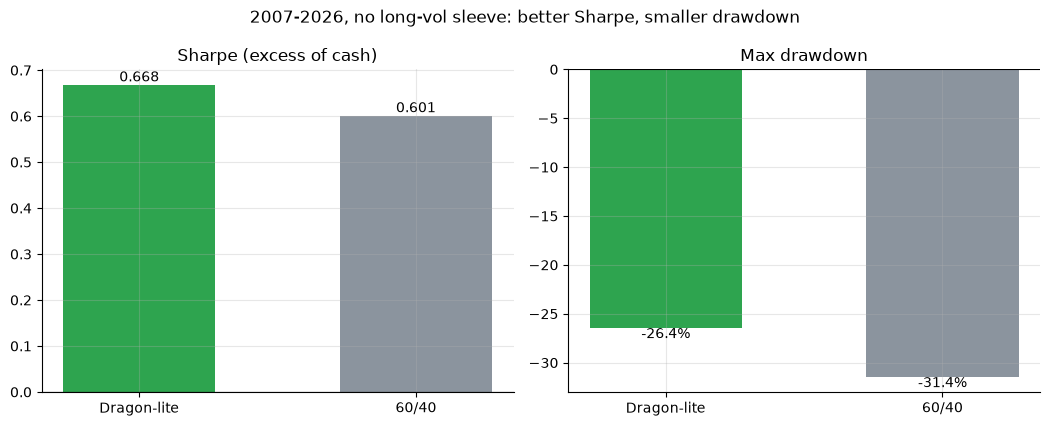

Dragon-lite Sharpe 0.668 vs 60/40 0.601  |  MaxDD -26.4% vs -31.4%


In [2]:
if HAVE_REAL:
    dlite = st.blended_portfolio(RET, st.DRAGON_LITE, cost_bps=5.0, start=data.CORE_START)
    p6040 = st.blended_portfolio(RET, st.SIXTY_FORTY, cost_bps=5.0, start=data.CORE_START)
    dl_s, p6_s = st.portfolio_stats(dlite, rf=RF), st.portfolio_stats(p6040, rf=RF)
    dl_sh, p6_sh, dl_dd, p6_dd = dl_s['sharpe'], p6_s['sharpe'], dl_s['max_dd']*100, p6_s['max_dd']*100
else:
    dl_sh, p6_sh, dl_dd, p6_dd = R['dl_sharpe'], R['p6040_core_sharpe'], R['dl_dd'], R['p6040_core_dd']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['Dragon-lite','60/40'], [dl_sh, p6_sh], color=[GREEN, GREY], width=.55)
for i,v in enumerate([dl_sh, p6_sh]): a1.annotate(f'{v:.3f}',(i,v),ha='center',va='bottom')
a1.set_title('Sharpe (excess of cash)'); a1.axhline(0, c='k', lw=.8)
a2.bar(['Dragon-lite','60/40'], [dl_dd, p6_dd], color=[GREEN, GREY], width=.55)
for i,v in enumerate([dl_dd, p6_dd]): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='top')
a2.set_title('Max drawdown'); a2.axhline(0, c='k', lw=.8)
plt.suptitle('2007-2026, no long-vol sleeve: better Sharpe, smaller drawdown')
plt.tight_layout(); plt.show()
print(f'Dragon-lite Sharpe {dl_sh:.3f} vs 60/40 {p6_sh:.3f}  |  '
      f'MaxDD {dl_dd:.1f}% vs {p6_dd:.1f}%')

Yes — the plain-vanilla kernel genuinely diversifies: Sharpe **0.67** vs 60/40's **0.60**, and a smaller drawdown (**-26%** vs **-31%**) — for a return forfeit of less than half a point a year. The quants notebook shows this gap isn't statistically certified with 19 years of data, but it's a real, honest edge on paper.

**Now add the real long-volatility sleeve** — the actual, full 5-sleeve Dragon:

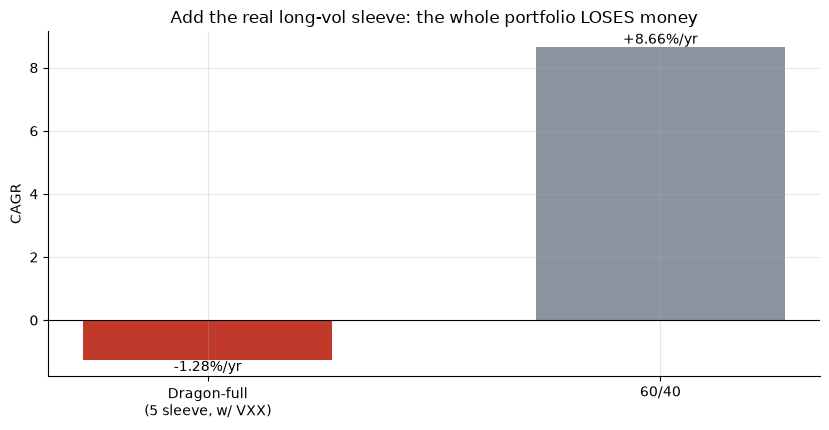

Dragon-full CAGR -1.28%/yr vs 60/40 +8.66%/yr


In [3]:
if HAVE_REAL:
    dfull = st.blended_portfolio(RET, st.DRAGON_FULL, cost_bps=5.0, start=data.FULL_START)
    p6f = st.blended_portfolio(RET, st.SIXTY_FORTY, cost_bps=5.0, start=data.FULL_START)
    df_s, p6f_s = st.portfolio_stats(dfull, rf=RF), st.portfolio_stats(p6f, rf=RF)
    df_cagr, p6f_cagr = df_s['cagr']*100, p6f_s['cagr']*100
else:
    df_cagr, p6f_cagr = R['df_cagr'], R['p6040_full_cagr']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['Dragon-full\n(5 sleeve, w/ VXX)','60/40'], [df_cagr, p6f_cagr],
       color=[RED, GREY], width=.55)
for i,v in enumerate([df_cagr, p6f_cagr]): ax.annotate(f'{v:+.2f}%/yr',(i,v),
    ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('CAGR')
ax.set_title('Add the real long-vol sleeve: the whole portfolio LOSES money')
plt.tight_layout(); plt.show()
print(f'Dragon-full CAGR {df_cagr:+.2f}%/yr vs 60/40 {p6f_cagr:+.2f}%/yr')

The full portfolio's CAGR is **-1.28%/yr — negative** — over the only window we can test (2018-2026), while 60/40 made **8.7%/yr** in the same stretch. That's the whole story in one bar chart. Why? Because the only cheap way to hold "long volatility" is a product that structurally bleeds:

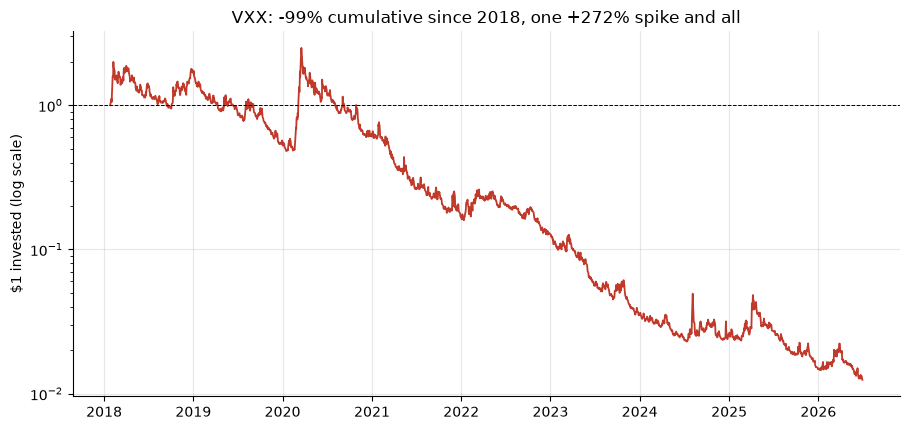

VXX cumulative return since inception: -98.8%   COVID spike (Feb19-Mar23 2020): +271.6%


In [4]:
if HAVE_REAL:
    vxx_ret = RET['VXX'].dropna()
    cum = (1.0 + vxx_ret).cumprod()
else:
    idx = pd.period_range('2018-01', periods=100, freq='M').to_timestamp()
    cum = pd.Series(np.geomspace(1.0, 1.0 + R['vxx_cum']/100, len(idx)), index=idx)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(cum.index, cum.values, color=RED, lw=1.3)
ax.set_yscale('log')
ax.axhline(1.0, c='k', lw=.7, ls='--')
ax.set_title(f'VXX: -{abs(R["vxx_cum"]):.0f}% cumulative since 2018, one +{R["vxx_covid"]:.0f}% spike and all')
ax.set_ylabel('$1 invested (log scale)')
plt.tight_layout(); plt.show()
print(f'VXX cumulative return since inception: {R["vxx_cum"]:+.1f}%   '
      f'COVID spike (Feb19-Mar23 2020): {R["vxx_covid"]:+.1f}%')

VXX lost **99%** of its value since 2018 — while paying off **+272%** in the six weeks of the COVID crash. That single spike is nowhere near enough to offset eight years of bleed at 21% portfolio weight. **This is the honest core finding:** the insurance is real (it fires exactly when it's supposed to) but it isn't cheap, and on this tape it hasn't yet paid for itself.

**And yet — look at the two crisis episodes side by side:**

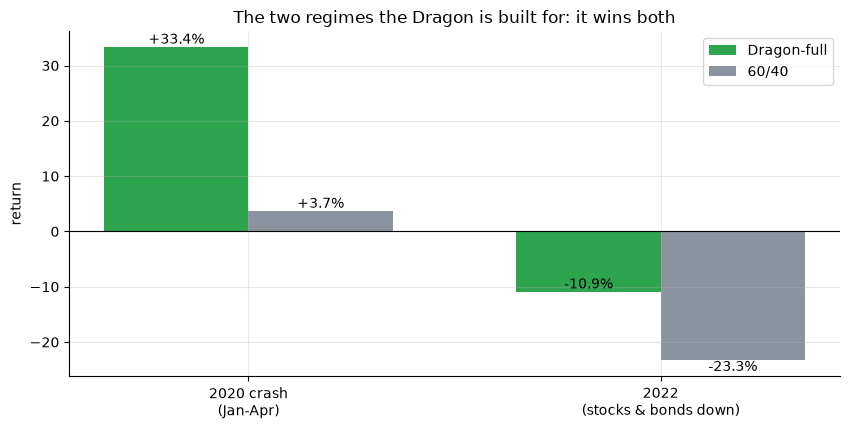

2020: Dragon +33.4% vs 60/40 +3.7%
2022: Dragon -10.9% vs 60/40 -23.3%


In [5]:
labels = ['2020 crash\n(Jan-Apr)', '2022\n(stocks & bonds down)']
dragon = [R['c2020_df'], R['y2022_df']]
sixforty = [R['c2020_6040'], R['y2022_6040']]
x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(x - w/2, dragon, w, label='Dragon-full', color=GREEN)
ax.bar(x + w/2, sixforty, w, label='60/40', color=GREY)
for i,v in enumerate(dragon): ax.annotate(f'{v:+.1f}%',(i-w/2,v),ha='center',va='bottom')
for i,v in enumerate(sixforty): ax.annotate(f'{v:+.1f}%',(i+w/2,v),ha='center',va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('return'); ax.legend()
ax.set_title('The two regimes the Dragon is built for: it wins both')
plt.tight_layout(); plt.show()
print(f'2020: Dragon {R["c2020_df"]:+.1f}% vs 60/40 {R["c2020_6040"]:+.1f}%')
print(f'2022: Dragon {R["y2022_df"]:+.1f}% vs 60/40 {R["y2022_6040"]:+.1f}%')

It genuinely wins both episodes — the deflationary crash AND the inflationary both-down year. That's real, useful diversification behavior. The catch is that "winning the crisis" and "making money overall" are two different questions, and on the tape we have, the answer to the second one is currently no.

## 5 · The verdict

- **Signal — Mixed.** Real diversification without the vol sleeve (better Sharpe, smaller drawdown than 60/40) — but not statistically certified. Real crisis-window wins in 2020 and 2022 with the vol sleeve — but the aggregate Sharpe over that same window is negative.
- **Tradability — Fragile.** Cheap and liquid, but the full published allocation lost money outright over the only window we can test.
- **"A cheap ETF Dragon just works?" — Busted.** The idea is sound; the cheap implementation of the insurance sleeve is the part that fails.

## 6 · Going further 🚪

- **The real Dragon Portfolio doesn't use VXX.** Cole's own firm runs an actively-managed options/variance book for the long-vol sleeve — sized, rolled and hedged dynamically. A buy-and-hold ETN is the cheapest possible substitute, and cheapest is not free.
- **We haven't seen a real secular inflation regime.** 2022 was one loud year; the 1970s were a decade. The claim that this mix survives a *multi-year* inflationary regime remains genuinely untested on public data.
- **Sibling studies:** [68-all-weather](../../68-all-weather/) (risk parity, no vol sleeve), [144-permanent-portfolio](../../144-permanent-portfolio/) (no trend or vol), [617-crash-insurance-cost](../../617-crash-insurance-cost/) (what standalone tail insurance costs), [655-ivy-portfolio](../../655-ivy-portfolio/) (trend-times everything, no vol).

*Think you can build the long-vol sleeve cheaper than VXX and keep the crisis payoff? Show a net Sharpe improvement over the whole sample — then we'll talk.*